In [ ]:
import sys
import datetime as dt
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.resampled_data_loader import get_resampled_quotes

instruments = ['USDSGD', 'EURUSD', 'AUDUSD', 'GBPUSD', 'USDJPY']

start_date = dt.datetime(2020, 1, 1)
end_date = dt.datetime(2025, 12, 31)
freq = pd.Timedelta(minutes=15)

prices = get_resampled_quotes(instruments, start_date, end_date, freq)

In [66]:
# reload
import importlib

import research.sgd_neer as sn
importlib.reload(sn)

import strategy.sgd_neer_strategy as sns
importlib.reload(sns)

import research.mean_reversion as mr
importlib.reload(mr)

import trading.aggressive_trader as at
importlib.reload(at)

<module 'trading.aggressive_trader' from '/Users/jinliu/Programming/Python/systematic-trading/src/systematic_trading/trading/aggressive_trader.py'>

In [67]:
strategy = sns.SGDNEERStrategy(instruments, prices,
                        {"past_horizon": pd.Timedelta(minutes=120),
                         "zscore_window": pd.Timedelta(days=20),
                         "future_horizon": pd.Timedelta(minutes=30),
                         "zscore_entry_threshold": 1.0,
                         "spread_rolling_window": pd.Timedelta(minutes=15),
                         "margin_multiple":0.5,
                         "adjust_to_target": True,
                         "delay_trade_on_signal": False
                        })


In [68]:
rets_vs_sgd = sn.build_rets_vs_sgd(prices)
index_ret_series = rets_vs_sgd["index"]
currency_ret_series = rets_vs_sgd["EUR"]

# Variance ratio of the index

<Axes: xlabel='interval_seconds'>

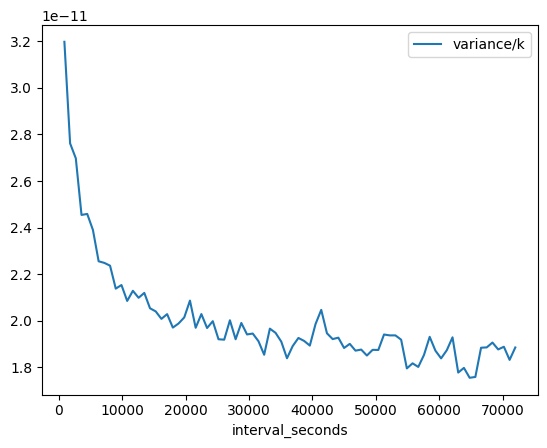

In [65]:
mr.variance_ratio(index_ret_series, pd.Timedelta(seconds=72000)).plot()

# Index spread

<Axes: xlabel='timestamp'>

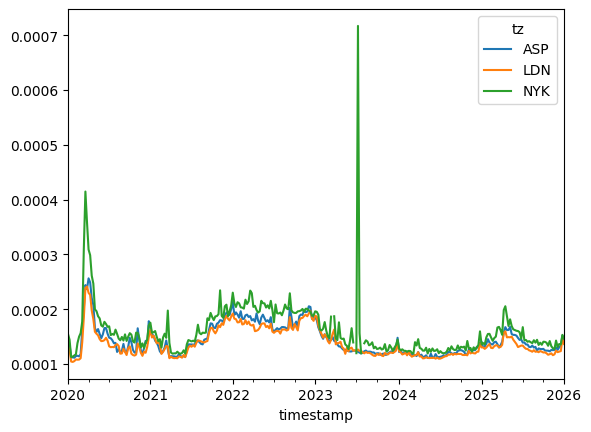

In [115]:
from util.time_util import attach_tz_column

index_spread = strategy._index_full_spread_cost().rename('spread')
index_spread = attach_tz_column(index_spread)
index_spread.groupby([pd.Grouper(freq='1W'), 'tz'])['spread'].quantile(0.5).unstack().plot()

In [97]:
df.groupby([pd.Grouper(freq="1W"), "tz_session"])["spread"].median().unstack('tz_session')

tz_session,ASP,LDN,NY
timestamp,,,
2020-01-05 00:00:00-05:00,0.000142,0.000132,0.000155
2020-01-12 00:00:00-05:00,0.000135,0.000126,0.000144
2020-01-19 00:00:00-05:00,0.000112,0.000104,0.000112
2020-01-26 00:00:00-05:00,0.000112,0.000104,0.000113
2020-02-02 00:00:00-05:00,0.000111,0.000105,0.000116
...,...,...,...
2025-12-07 00:00:00-05:00,0.000126,0.000122,0.000131
2025-12-14 00:00:00-05:00,0.000130,0.000122,0.000136
2025-12-21 00:00:00-05:00,0.000133,0.000123,0.000135


# MR regression heatmap for index and component ccy (SGDXXX)

In [11]:
past_horizons = [
    pd.Timedelta(minutes=15),
    pd.Timedelta(minutes=30),
    pd.Timedelta(minutes=60),
    pd.Timedelta(minutes=120),
]

future_horizons = [
    pd.Timedelta(minutes=15),
    pd.Timedelta(minutes=30),
    pd.Timedelta(minutes=60),
]

rets_vs_sgd = sn.build_rets_vs_sgd(prices)

frames = [
    mr.return_regression_heatmap(
        rets_vs_sgd[ccy], past_horizons, future_horizons, pd.Timedelta(days=5)
    )
    for ccy in rets_vs_sgd.columns
]

results = pd.concat(frames, axis=0)
results

,name,past_period,future_period,past_period_seconds,future_period_seconds,abs_z_bucket,correlation,beta,n_observations,r_squared,alpha,p_value,std_err
0,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,"(0,0.5)",-0.041490,-0.130840,66568,0.001721,9.019514e-07,9.215120e-27,0.012212
1,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,"(0.5,1)",-0.086152,-0.110625,40123,0.007422,-2.602923e-07,5.748897e-67,0.006387
2,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,"(1,2)",-0.130425,-0.103759,27247,0.017011,3.030083e-06,1.158207e-103,0.004779
3,index,0 days 00:15:00,0 days 00:15:00,900.0,900.0,"(2,inf)",-0.226278,-0.121807,6991,0.051202,-1.622665e-06,7.217445e-82,0.006272
4,index,0 days 00:15:00,0 days 00:30:00,900.0,1800.0,"(0,0.5)",-0.034961,-0.148866,66416,0.001222,7.621835e-07,2.015631e-19,0.016513
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,GBP,0 days 02:00:00,0 days 00:30:00,7200.0,1800.0,"(2,inf)",-0.069248,-0.018119,8718,0.004795,3.171229e-05,9.637493e-11,0.002796
44,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,"(0,0.5)",-0.015152,-0.033109,66026,0.000230,-3.642776e-06,9.883743e-05,0.008503
45,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,"(0.5,1)",-0.025356,-0.025816,37517,0.000643,1.827687e-06,9.020941e-07,0.005255
46,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,"(1,2)",-0.032570,-0.019497,26973,0.001061,1.468185e-06,8.782694e-08,0.003643


In [12]:
results.to_csv('tmp.csv')

# Panel regression stats for each component ccy

In [ ]:
past_horizons = [
    pd.Timedelta(minutes=15),
    pd.Timedelta(minutes=30),
    pd.Timedelta(minutes=60),
    pd.Timedelta(minutes=120),
]

future_horizons = [
    pd.Timedelta(minutes=15),
    pd.Timedelta(minutes=30),
    pd.Timedelta(minutes=60),
]

rets_vs_sgd = sn.build_rets_vs_sgd(prices)
index_ret_series = rets_vs_sgd["index"]

frames = [
    sn.panel_regression_heatmap(
        index_ret_series,
        rets_vs_sgd[ccy],
        past_horizons,
        future_horizons,
        pd.Timedelta(days=5),
    )
    for ccy in rets_vs_sgd.columns
    if ccy != "index"
]

pd.concat(frames, axis=0)

,name,past_period,future_period,past_period_seconds,future_period_seconds,abs_z_bucket,index_correlation,relative_correlation,relative_beta,index_beta,n_observations,r_squared,alpha,relative_p_value,index_p_value,relative_std_err,index_std_err
0,USD,0 days 00:15:00,0 days 00:15:00,900.0,900.0,0-0.5,-0.071117,0.009276,0.014393,-0.115208,70646,0.005073,-3.971717e-07,2.949837e-01,8.481942e-79,0.013744,0.006122
1,USD,0 days 00:15:00,0 days 00:15:00,900.0,900.0,0.5-1,-0.043733,0.019286,0.018777,-0.066684,38284,0.002070,7.476710e-07,1.388618e-02,7.132769e-16,0.007632,0.008261
2,USD,0 days 00:15:00,0 days 00:15:00,900.0,900.0,1-2,-0.069867,0.012703,-0.004450,-0.107793,25057,0.004905,-2.311009e-07,4.454245e-01,9.786515e-28,0.005831,0.009864
3,USD,0 days 00:15:00,0 days 00:15:00,900.0,900.0,2-inf,-0.031432,-0.003573,-0.009700,-0.049285,7039,0.001315,9.325107e-06,1.291497e-01,2.463766e-03,0.006392,0.016272
4,USD,0 days 00:15:00,0 days 00:30:00,900.0,1800.0,0-0.5,-0.066447,0.003483,-0.007627,-0.149446,70524,0.004417,-1.356429e-07,6.879256e-01,1.104831e-69,0.018988,0.008460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,GBP,0 days 02:00:00,0 days 00:30:00,7200.0,1800.0,2-inf,-0.022263,-0.061208,-0.017190,-0.030910,9261,0.004255,2.553560e-05,3.502124e-09,2.974363e-02,0.002908,0.014219
44,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,0-0.5,-0.057962,0.007747,0.009066,-0.099057,68874,0.003375,-2.457630e-06,3.079443e-01,1.161774e-51,0.008892,0.006545
45,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,0.5-1,-0.038912,-0.023034,-0.028986,-0.075731,35592,0.002181,-4.036059e-06,1.077760e-06,1.722959e-14,0.005943,0.009870
46,GBP,0 days 02:00:00,0 days 01:00:00,7200.0,3600.0,1-2,-0.033475,0.011237,0.006361,-0.064200,24986,0.001217,1.156021e-05,1.212016e-01,1.780621e-07,0.004104,0.012293


# Optimise MR rolling return regression

In [7]:
mr.optimise_rolling_return_regression(index_ret_series, "net_sharpe")

,past_horizon,future_horizon,lookback_window,tcost_bps,margin_multiple,adjust_to_target,pred_zs_threshold,net_sharpe,gross_sharpe,frictionless_sharpe
9,0 days 01:00:00,0 days 00:15:00,5 days,1.0,0.5,True,0.5,2.985288,4.914332,6.575538
8,0 days 01:00:00,0 days 00:15:00,5 days,1.0,0.5,True,0.0,2.961501,4.908494,6.686849
10,0 days 01:00:00,0 days 00:15:00,5 days,1.0,0.5,True,1.0,2.942093,4.776546,6.118102
11,0 days 01:00:00,0 days 00:15:00,5 days,1.0,0.5,True,1.5,2.837675,4.636846,5.531533
82,0 days 01:00:00,0 days 00:30:00,5 days,1.0,1.0,True,1.0,2.689114,3.741281,5.585944
...,...,...,...,...,...,...,...,...,...,...
96,0 days 01:00:00,0 days 00:30:00,5 days,2.0,0.0,True,0.0,-5.527329,6.112008,6.112008
37,0 days 01:00:00,0 days 00:15:00,5 days,2.0,0.0,False,0.5,-6.490184,6.575538,6.575538
33,0 days 01:00:00,0 days 00:15:00,5 days,2.0,0.0,True,0.5,-6.490184,6.575538,6.575538
36,0 days 01:00:00,0 days 00:15:00,5 days,2.0,0.0,False,0.0,-6.924185,6.686849,6.686849


In [ ]:
import itertools


def sweep_parameters_panel(
    df_base,
    tcost_bps=1.0,
    margin_multiples=np.arange(0.0, 2.0, 0.1),
    adjust_to_target_values=[True, False],
    pred_zs_thresholds=np.arange(0.0, 2.0, 0.2),
):
    results = []

    for margin_multiple, adjust_to_target, pred_zs_threshold in itertools.product(
        margin_multiples, adjust_to_target_values, pred_zs_thresholds
    ):
        df = df_base.copy()
        df = apply_position(
            df,
            tcost_bps=tcost_bps,
            margin_multiple=margin_multiple,
            adjust_to_target=adjust_to_target,
            pred_zs_threshold=pred_zs_threshold,
            delay_trade_on_signal=False
        )

        df["frictionless_pnl"] = df["target_position"].shift(1) * df["ret"]
        df["gross_pnl"] = df["position"].shift(1) * df["ret"]
        df["net_pnl"] = (
            df["gross_pnl"] - 0.5 * df["tcost"] * df["position"].diff().abs()
        )

        results.append(
            {
                "margin_multiple": margin_multiple,
                "adjust_to_target": adjust_to_target,
                "pred_zs_threshold": pred_zs_threshold,
                "net_sharpe": sharpe(df["net_pnl"]),
                "gross_sharpe": sharpe(df["gross_pnl"]),
                "frictionless_sharpe": sharpe(df["frictionless_pnl"].dropna()),
            }
        )

    sweep = pd.DataFrame(results).sort_values("net_sharpe", ascending=False)
    return sweep


# --- Run sweep ---
# Build base df once (avoid recomputing regression)
past_horizon = pd.Timedelta(hours=2)
future_horizon = pd.Timedelta(minutes=15)
lookback_window = pd.Timedelta(days=5)

currency_ret_series = strategy.build_rets_vs_sgd()["EUR"]

df_base = rolling_panel_regression(index_ret_series, currency_ret_series, past_horizon, future_horizon, lookback_window)
df_base = df_base.join(currency_ret_series.rename("ret"), how="left")

sweep = sweep_parameters_panel(df_base, tcost_bps=1.0)

# --- Best parameter set ---
best = sweep.iloc[0]
print(sweep.to_string(index=False))
print(
    f"\nBest: margin_multiple={best['margin_multiple']}, "
    f"adjust_to_target={best['adjust_to_target']}, "
    f"pred_zs_threshold={best['pred_zs_threshold']}, "
    f"net_sharpe={best['net_sharpe']:.2f}, "
)

 margin_multiple  adjust_to_target  pred_zs_threshold  net_sharpe  gross_sharpe  frictionless_sharpe
             0.1              True                0.0    3.342174      5.204869             5.398858
             0.2              True                0.0    3.288763      4.775862             5.398858
             0.2              True                0.4    3.285554      4.862944             5.268957
             0.1              True                0.6    3.277095      5.105667             5.188709
             0.1              True                0.4    3.271508      5.160976             5.268957
             0.1              True                1.0    3.268926      4.860309             4.901317
             0.1              True                0.2    3.266834      5.195149             5.344951
             0.1              True                0.8    3.266168      5.004009             5.064394
             0.2              True                0.6    3.265802      4.860910            

In [72]:
signals = strategy.generate_signals()

look here USD
look here EUR
look here JPY
look here AUD
look here GBP


In [73]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(instruments, prices, signals)

report = PerformanceReport(instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
USDSGD,0.72942,0.729423,1.864445,-0.0,-0.0,0.0,0.0,0 days 04:35:30.136986,0 days 01:30:00,0 days 00:30:00,0 days 08:15:00
EURUSD,-0.079594,-0.07959,1.864445,-0.000001,-0.0,-0.0,-0.0,0 days 04:35:30.136986,0 days 01:30:00,0 days 00:30:00,0 days 08:15:00
AUDUSD,0.038284,0.03829,1.864445,-0.000001,-0.0,0.0,0.0,0 days 04:35:30.136986,0 days 01:30:00,0 days 00:30:00,0 days 08:15:00
GBPUSD,0.081956,0.081957,1.864445,-0.0,-0.0,0.0,0.0,0 days 04:35:30.136986,0 days 01:30:00,0 days 00:30:00,0 days 08:15:00
USDJPY,0.00843,0.008433,1.864445,-0.000001,-0.0,0.0,0.0,0 days 04:35:30.136986,0 days 01:30:00,0 days 00:30:00,0 days 08:15:00


<Axes: title={'center': 'USDSGD Cumulative PnL'}, xlabel='Time', ylabel='Cumulative PnL'>

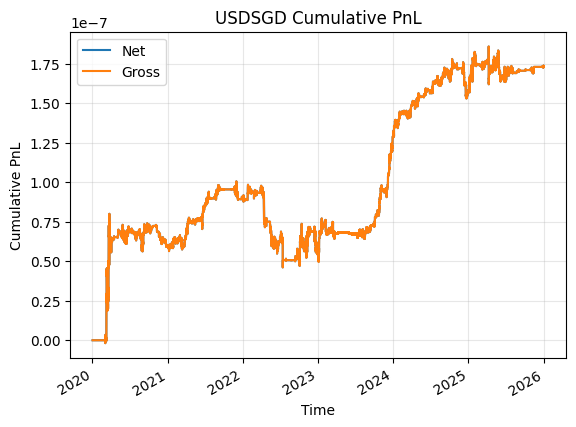

In [75]:
report.plot_cumulative_pnl('USDSGD')

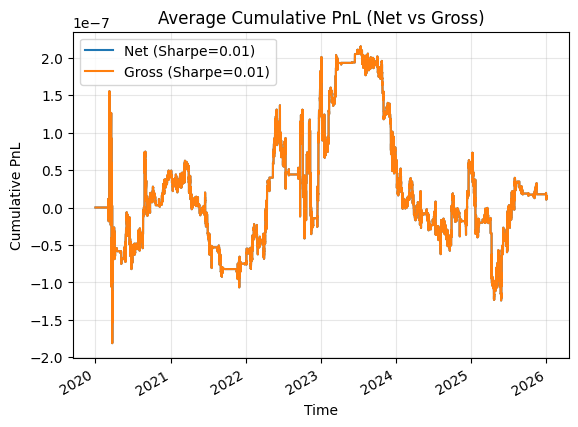

In [74]:
import numpy as np

freq_mult = pd.Timedelta(days=1) / freq

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * freq_mult) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * freq_mult) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


# Wild swings in index: after NFP 3rd Jul 2025

<Axes: xlabel='timestamp'>

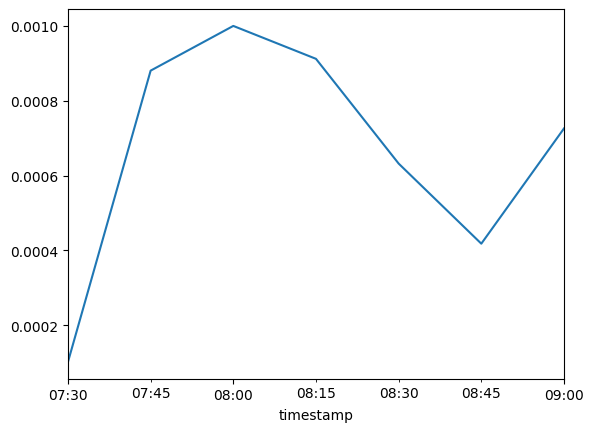

In [64]:
index_ret_series.loc['2025-07-03 07:30' : '2025-07-03 09:00'].cumsum().plot()